In [104]:
import contextlib
import io
import multiprocessing as mp
import os.path
import time
from collections import OrderedDict, namedtuple
from copy import copy
from functools import partial
from typing import Dict

import matplotlib.pyplot as plt


import sys
sys.path.insert(0,'/home/rebecca/Documents/code/fork_drake/drake-build/install/lib/python3.10/site-packages')

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from iris_environments.environments import env_names, get_environment_builder, get_robot_instance_names

import numpy as np
import pydot
from IPython.display import SVG, display
from pydrake.all import (
    Context,
    IrisFromCliqueCoverOptions,
    IrisInConfigurationSpaceFromCliqueCover,
    Meshcat,
    MeshcatPoseSliders,
    RandomGenerator,
    RobotDiagramBuilder,
    SceneGraph,
    SceneGraphCollisionChecker,
    RandomGenerator,
    IrisNp2Options, IrisNp2SamplingStrategy, IrisNp2,
    IrisZo,
    IrisZoOptions,
    GurobiSolver,
    MosekSolver
)
from pydrake.common.value import AbstractValue
from pydrake.geometry import (
    Meshcat,
    MeshcatVisualizer,
    QueryObject,
    Rgba,
    Role,
    SceneGraph,
    Sphere,
    StartMeshcat,
)
from pydrake.geometry.optimization import (
    AffineBall,
    GraphOfConvexSetsOptions,
    HPolyhedron,
    VPolytope,
    Hyperellipsoid,
    IrisInConfigurationSpace,
    IrisOptions,
    LoadIrisRegionsYamlFile,
    Point,
    SaveIrisRegionsYamlFile,
)
from pydrake.math import RigidTransform, RollPitchYaw, RotationMatrix
from pydrake.multibody.inverse_kinematics import InverseKinematics
from pydrake.multibody.meshcat import JointSliders
from pydrake.multibody.parsing import PackageMap, Parser
from pydrake.multibody.plant import AddMultibodyPlantSceneGraph, MultibodyPlant
from pydrake.multibody.tree import Body
from pydrake.planning import (
    GcsTrajectoryOptimization,
    MaxCliqueSolverViaGreedy,
    VisibilityGraph,
)
from pydrake.solvers import MathematicalProgram, Solve
from pydrake.systems.framework import DiagramBuilder, LeafSystem
from pydrake.visualization import AddDefaultVisualization, ModelVisualizer

import pickle 



In [59]:
env_name = '3DOFFLIPPER'
plant_builder = get_environment_builder(env_name)
plant, scene_graph, diagram, diagram_context, plant_context, _ = plant_builder(usemeshcat=False)
    
meshcat = StartMeshcat()

INFO:drake:Meshcat listening for connections at http://localhost:7005
INFO:drake:Meshcat listening for connections at http://localhost:7007


/home/rebecca/Documents/code/iris_benchmarks/iris_environments/assets/box_small.urdf
http://localhost:7005


In [60]:
iris_options = IrisOptions()
iris_options.iteration_limit = 10
# increase num_collision_infeasible_samples to improve the (probabilistic)
# certificate of having no collisions.
iris_options.num_collision_infeasible_samples = 3
iris_options.require_sample_point_is_contained = True
iris_options.relative_termination_threshold = 0.01
iris_options.termination_threshold = -1

# Additional options for this notebook:

# If use_existing_regions_as_obstacles is True, then iris_regions will be
# shrunk by regions_as_obstacles_margin, and then passed to
# iris_options.configuration_obstacles.
use_existing_regions_as_obstacles = True
regions_as_obstacles_scale_factor = 0.95

# We can compute some regions in parallel.
num_parallel = mp.cpu_count()

In [61]:
def ScaleHPolyhedron(hpoly, scale_factor):
    # Shift to the center.
    xc = hpoly.ChebyshevCenter()
    A = hpoly.A()
    b = hpoly.b() - A @ xc
    # Scale
    b = scale_factor * b
    # Shift back
    b = b + A @ xc
    return HPolyhedron(A, b)


def _CheckNonEmpty(region):
    prog = MathematicalProgram()
    x = prog.NewContinuousVariables(region.ambient_dimension())
    region.AddPointInSetConstraints(prog, x)
    result = Solve(prog)
    assert result.is_success()


def _CalcRegionNP(plant, plant_context, name, seed):
    plant.SetPositions(plant_context, seed)
    #TODO where to do options
    display(f"Computing region for seed: {name}")
    start_time = time.time()
    hpoly = IrisInConfigurationSpace(plant, plant_context, iris_options)
    display(
        f"Finished seed {name}; Computation time: {(time.time() - start_time):.2f} seconds"
    )

    _CheckNonEmpty(hpoly)
    reduced = hpoly.ReduceInequalities()
    _CheckNonEmpty(reduced)

    return reduced


def DrawRobot(query_object: QueryObject, meshcat_prefix: str, draw_world: bool = True):
    rgba = Rgba(0.7, 0.7, 0.7, 0.3)
    role = Role.kProximity
    # This is a minimal replication of the work done in MeshcatVisualizer.
    inspector = query_object.inspector()
    for frame_id in inspector.GetAllFrameIds():
        if frame_id == inspector.world_frame_id():
            if not draw_world:
                continue
            frame_path = meshcat_prefix
        else:
            frame_path = f"{meshcat_prefix}/{inspector.GetName(frame_id)}"
        frame_path.replace("::", "/")
        frame_has_any_geometry = False
        for geom_id in inspector.GetGeometries(frame_id, role):
            path = f"{frame_path}/{geom_id.get_value()}"
            path.replace("::", "/")
            meshcat.SetObject(path, inspector.GetShape(geom_id), rgba)
            meshcat.SetTransform(path, inspector.GetPoseInFrame(geom_id))
            frame_has_any_geometry = True

        if frame_has_any_geometry:
            X_WF = query_object.GetPoseInWorld(frame_id)
            meshcat.SetTransform(frame_path, X_WF)


def VisualizeRegion(region_name, num_to_draw=30, draw_illustration_role_once=True):
    """
    A simple hit-and-run-style idea for visualizing the IRIS regions:
    1. Start at the center. Pick a random direction and run to the boundary.
    2. Pick a new random direction; project it onto the current boundary, and run along it. Repeat
    """

    builder = DiagramBuilder()
    plant, scene_graph = AddMultibodyPlantSceneGraph(builder, time_step=0.0)
    LoadRobot(plant)
    plant.Finalize()
    if draw_illustration_role_once:
        MeshcatVisualizer.AddToBuilder(builder, scene_graph, meshcat)
    diagram = builder.Build()
    context = diagram.CreateDefaultContext()
    plant_context = plant.GetMyMutableContextFromRoot(context)
    scene_graph_context = scene_graph.GetMyContextFromRoot(context)

    global iris_regions
    region = iris_regions[region_name]

    q = region.ChebyshevCenter()
    plant.SetPositions(plant_context, q)
    diagram.ForcedPublish(context)

    query = scene_graph.get_query_output_port().Eval(scene_graph_context)
    DrawRobot(query, f"{region_name}/0", True)

    rng = np.random.default_rng()
    nq = plant.num_positions()
    prog = MathematicalProgram()
    qvar = prog.NewContinuousVariables(nq, "q")
    prog.AddLinearConstraint(region.A(), 0 * region.b() - np.inf, region.b(), qvar)
    cost = prog.AddLinearCost(np.ones((nq, 1)), qvar)

    for i in range(1, num_to_draw):
        direction = rng.standard_normal(nq)
        cost.evaluator().UpdateCoefficients(direction)

        result = Solve(prog)
        assert result.is_success()

        q = result.GetSolution(qvar)
        plant.SetPositions(plant_context, q)
        query = scene_graph.get_query_output_port().Eval(scene_graph_context)
        DrawRobot(query, f"{region_name}/{i}", False)


def VisualizeRegions():
    for k in iris_regions.keys():
        meshcat.Delete()
        VisualizeRegion(k)
        button_name = f"Visualizing {k}; Press for next region"
        meshcat.AddButton(button_name, "Enter")
        print("Press Enter to visualize the next region")
        while meshcat.GetButtonClicks(button_name) < 1:
            time.sleep(1.0)
        meshcat.DeleteButton(button_name)


class PoseSelector(LeafSystem):
    def __init__(
        self,
        body_index=None,
    ):
        LeafSystem.__init__(self)
        self._body_index = body_index
        self.DeclareAbstractInputPort(
            "body_poses", AbstractValue.Make([RigidTransform()])
        )
        self.DeclareAbstractOutputPort(
            "pose",
            lambda: AbstractValue.Make(RigidTransform()),
            self.CalcOutput,
        )

    def CalcOutput(self, context, output):
        body_poses = self.get_input_port().Eval(context)
        output.set_value(body_poses[self._body_index])

def save_ellipsoids(ellipsoids, fname = 'ellipsoids'):
    ellipsoid_data = []
    for ellipsoid in ellipsoids:
        A = ellipsoid.A()
        center = ellipsoid.center()
        ellipsoid_data.append({'A': A, 'center': center})

    # Save to file
    with open(fname + '.pkl', 'wb') as f:
        pickle.dump(ellipsoid_data, f)

In [62]:
meshcat.Delete()
meshcat.DeleteAddedControls()

rob_names = get_robot_instance_names(env_name)
robot_instances = [plant.GetModelInstanceByName(n) for n in rob_names]
checker = SceneGraphCollisionChecker(model = diagram.Clone(), 
                robot_model_instances = robot_instances,
                #configuration_distance_function = _configuration_distance,
                edge_step_size = 0.125)


INFO:drake:Allocating contexts to support implicit context parallelism 32


In [63]:
def uniform_sampler(num_samples, seed=None):
    # domain = HPolyhedron.MakeBox(checker.plant().GetPositionLowerLimits(),
    #                              checker.plant().GetPositionUpperLimits())
    

    # generator=RandomGenerator()

    # points = np.zeros(domain.ambient_dimension(), num_samples)

    # num_pts_collision_free = 0
    # previous_sample
    # while num_pts_collision_free < num_samples:
    #     sample = domain.UniformSample(generator, )
    if seed:
        np.random.seed(seed)

    lbs = checker.plant().GetPositionLowerLimits()
    ubs = checker.plant().GetPositionUpperLimits()

    dim = len(lbs)

    pts = lbs + (ubs - lbs) * np.random.rand(num_samples, dim)
    col_free = checker.CheckConfigsCollisionFree(pts, parallelize=True)

    return pts[np.array(col_free, dtype=bool)]

In [64]:
lbs = checker.plant().GetPositionLowerLimits()
ubs = checker.plant().GetPositionUpperLimits()

In [65]:
num_nodes = 2500
nodes = uniform_sampler(num_nodes,seed=0)
adjacency_matrix = VisibilityGraph(
    checker, np.array(nodes).T, parallelize=True
)
print(len(nodes))

373


In [66]:
from cspace_utils.plotting import plot_points
from pydrake.all import Rgba
meshcat.Delete()

plot_points(meshcat, nodes, 'bla', 0.01)


In [67]:
def truncated_clique_cover(adjacency_matrix, min_clique_size=20):
    cliques = []
    done = False
    adj_curr = adjacency_matrix.copy()
    ind_curr = np.arange(adj_curr.shape[0])
    while not done:
        solver = MaxCliqueSolverViaGreedy()
        part_of_clique = solver.SolveMaxClique(adj_curr)
        ind_max_clique_local = np.where(part_of_clique)[0]
        index_max_clique_global = np.array([ind_curr[i] for i in ind_max_clique_local])
        cliques.append(index_max_clique_global.reshape(-1))
        adj_curr = adj_curr[~part_of_clique][:, ~part_of_clique]
        ind_curr = ind_curr[~part_of_clique]
        if adj_curr.shape[0] == 0 or len(cliques[-1]) < min_clique_size:
            done = True
    return cliques

def double_greedy_clique_cover(adjacency_matrix, min_clique_size=8):
    cliques = []
    done = False
    adj_curr = adjacency_matrix.copy()
    ind_curr = np.arange(adj_curr.shape[0])
    while not done:
        print(f"[CCDGDRAKE] remaining nodes {adj_curr.shape[0]}")
        solver = MaxCliqueSolverViaGreedy()
        part_of_clique = solver.SolveMaxClique(adj_curr)
        ind_max_clique_local = np.where(part_of_clique)[0]
        index_max_clique_global = np.array([ind_curr[i] for i in ind_max_clique_local])
        cliques.append(index_max_clique_global.reshape(-1))
        adj_curr = adj_curr[~part_of_clique][:, ~part_of_clique]
        ind_curr = ind_curr[~part_of_clique]
        if adj_curr.shape[0] == 0 or len(cliques[-1]) < min_clique_size:
            done = True
    return cliques

cliques = double_greedy_clique_cover(adjacency_matrix)
clique_nodes = [np.array(nodes)[c] for c in cliques]
print(f"found {len(cliques)} cliques")

[CCDGDRAKE] remaining nodes 373
[CCDGDRAKE] remaining nodes 191
[CCDGDRAKE] remaining nodes 144
[CCDGDRAKE] remaining nodes 101
[CCDGDRAKE] remaining nodes 59
[CCDGDRAKE] remaining nodes 36
[CCDGDRAKE] remaining nodes 20
found 7 cliques


In [68]:
from cspace_utils.plotting import plot_cliques

plot_cliques(meshcat, cliques, nodes, 'cliques')

In [69]:
ellipsoids = []
# the solutions will often be of lower rank, therefore we need to handle that case somewhat carefully
for n in clique_nodes:
    ab = AffineBall.MinimumVolumeCircumscribedEllipsoid(n.T)
    u, s, vt = np.linalg.svd(ab.B())
    # forcing the ellipsoids to have volume
    for i in range(s.shape[0]):
        if s[i] < 1e-4:
            s[i] = 1e-4
            print("Here")
    B_corrected = u @ np.diag(s) @ vt
    ellipsoids.append(Hyperellipsoid(AffineBall(B_corrected, ab.center())))

In [ ]:
# save_ellipsoids(ellipsoids)

In [92]:
method = "greedy"

In [164]:
IrisNp2Options().ray_sampler_options.only_walk_toward_collisions

False

In [93]:
def call_IRIS(plant, plant_context, e, options, method="NP"):
    domain = HPolyhedron.MakeBox(plant.GetPositionLowerLimits(),
                                 plant.GetPositionUpperLimits())
    if method == "NP":
        return IrisInConfigurationSpace(plant, plant_context, options)
    elif method == "ray":
        options.sampling_strategy = IrisNp2SamplingStrategy.kRaySampler
        return IrisNp2(checker, e, domain, options)
    elif method == "greedy":
        options.sampling_strategy = IrisNp2SamplingStrategy.kGreedySampler
        return IrisNp2(checker, e, domain, options)
    elif method == "Zo":
        return IrisZo(checker, e, domain, options)
    else:
        return None

In [94]:
# VCC only requires 1 iteration, increasing this will likely worsen the results
c_space_margin = 0.01
if method == "NP":
    options = IrisOptions()
    options.iteration_limit = 1
    options.configuration_space_margin = c_space_margin
elif method == "Zo":
    options = IrisZoOptions()
    options.sampled_iris_options.max_iterations = 1
    options.sampled_iris_options.configuration_space_margin = c_space_margin
else:
    options = IrisNp2Options()
    options.sampled_iris_options.max_iterations = 1
    options.sampled_iris_options.configuration_space_margin = c_space_margin
# the shelve is tight so we need to lower this margin to be able to find regions

regions = []
for i, e in enumerate(ellipsoids):
    print(f"Building region {i}")
    if not checker.CheckConfigCollisionFree(e.center()):
        e = Hyperellipsoid(e.A(), clique_nodes[i][0])
        print(f"WARNING the center of ellipsoid {i} is in collision")

    if method == "NP":
        options.starting_ellipse = e
    plant.SetPositions(plant_context, e.center())
    try:
        # region = IrisInConfigurationSpace(plant, plant_context, e, vcc_iris_options)
        region = call_IRIS(plant, plant_context, e, options, method)
        print("HERE")
        regions.append(region)
        print(f"Finished building region with {len(region.b())} faces")
    except:
        print(
            "IRIS call failed."
        )

INFO:drake:IrisNp2 iteration 0
INFO:drake:IrisNp2 iteration 0


Building region 0
HERE
Finished building region with 18 faces
Building region 1


INFO:drake:IrisNp2 iteration 0
INFO:drake:IrisNp2 iteration 0


HERE
Finished building region with 22 faces
Building region 2
HERE
Finished building region with 14 faces
Building region 3


INFO:drake:IrisNp2 iteration 0
INFO:drake:IrisNp2 iteration 0


HERE
Finished building region with 22 faces
Building region 4
HERE
Finished building region with 14 faces
Building region 5


INFO:drake:IrisNp2 iteration 0


HERE
Finished building region with 17 faces
Building region 6
HERE
Finished building region with 16 faces


In [95]:
from cspace_utils.plotting import plot_regions

plot_regions(meshcat, regions)



In [96]:
from cspace_utils.sampling import point_in_regions

s = uniform_sampler(1000000)


n_s = 0
for n in s:
    if point_in_regions(n, regions):
        n_s +=1

print(f"c = {n_s/len(s)}")

c = 0.8668954380298749


In [97]:
def compare_regions_to_cliques(clique_nodes, regions):
    for i in range(len(clique_nodes)):
        clique_vpoly = VPolytope(np.array(clique_nodes[i]).T)
        region_vpoly = VPolytope(regions[i])

        clique_hpoly = HPolyhedron(clique_vpoly)

        intersection_hpoly = clique_hpoly.Intersection(regions[i])

        if intersection_hpoly.IsEmpty():
            intersection_volume = 0
        else:
            intersection_vpoly = VPolytope(intersection_hpoly)
            intersection_volume = intersection_vpoly.CalcVolume()

        region_volume = region_vpoly.CalcVolume()

        clique_volume = clique_vpoly.CalcVolume()

        print(f"Region {i}: Intersection occupies {100*intersection_volume/clique_volume}% of clique and {100*intersection_volume/region_volume}% of region")

In [98]:

def resize_svg(svg_b, width_user: int):
    svg_content = svg_b.decode("utf-8")

    svg_start = svg_content.find('<svg width="')
    width_start = svg_start + 12  # Length of '<svg width="'
    width_end = svg_content.find('pt"', width_start)
    height_start = svg_content.find('height="', width_end) + 8  # Length of 'height="'
    height_end = svg_content.find('pt"', height_start)
    width = float(svg_content[width_start:width_end])
    height = float(svg_content[height_start:height_end])

    # Calculate the new height
    new_width = width_user
    new_height = int(width_user / width * height)

    # Create the new svg tag
    new_svg_tag = f'<svg width="{new_width}pt" height="{new_height}pt" '

    # Replace the old svg tag with the new one
    svg_str = svg_content[:svg_start] + new_svg_tag + svg_content[height_end + 3 :]
    return svg_str.encode("utf-8")


# plotting function for later
def plot_region_connectivity(
    regions: list[HPolyhedron], labels: list[str], colors: list[str], width: int
):
    graph = pydot.Dot("Intersection graph", rankdir="TB")
    graph.set("mode", "hier")
    graph.set("overlap", "false")

    for i, l in enumerate(labels):
        graph.add_node(pydot.Node(l, color=colors[i]))
    for i in range(len(labels)):
        v1 = regions[i]
        for j in range(i + 1, len(labels)):
            v2 = regions[j]
            if v1.IntersectsWith(v2):
                graph.add_edge(pydot.Edge(labels[i], labels[j], dir="both"))
    svg = graph.create_svg()
    display(SVG(resize_svg(svg, width)))

Connectivity graph of the regions


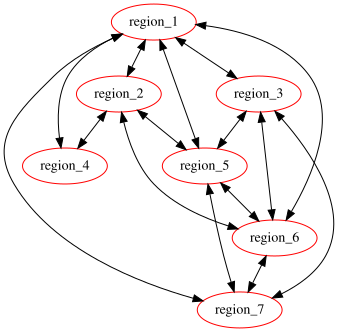

Estimated coverage of our distribution: Out of 10000 samples, a fraction of 0.1301 are contained in the 7 regions.


In [99]:
def point_in_regions(regions, point):
    for r in regions:
        if r.PointInSet(point):
            return True
    return False


regions_to_plot = regions
labels_regions_tot = [
    f"region_{i+1}" for i in range(len(regions))
]
colors = ["red"] * len(regions)

title = f"Connectivity graph of the regions"
print(title)

plot_region_connectivity(regions_to_plot, labels_regions_tot, colors, width=800)

num_samples = 10000

q_cov = uniform_sampler(num_samples)
est_cov = 0
for q in q_cov:
    if point_in_regions(regions, q):
        est_cov += 1
print(
    f"Estimated coverage of our distribution: Out of {num_samples} samples, a fraction of {est_cov/num_samples} are contained in the {len(regions)} regions."
)

In [100]:
compare_regions_to_cliques(clique_nodes, regions)

Region 0: Intersection occupies 95.41902508415347% of clique and 81.30317518686986% of region
Region 1: Intersection occupies 91.18553090805449% of clique and 40.25386799608529% of region
Region 2: Intersection occupies 89.45359150522641% of clique and 30.112876416676304% of region
Region 3: Intersection occupies 98.94421384137327% of clique and 53.263834692120184% of region
Region 4: Intersection occupies 98.84677497177324% of clique and 9.671957239323566% of region
Region 5: Intersection occupies 96.45906157836033% of clique and 13.770158513092847% of region
Region 6: Intersection occupies 96.95618863076649% of clique and 2.1159830998225373% of region


In [101]:
len(regions)

7

In [172]:
IrisNp2Options()

IrisNp2Options(sampled_iris_options=CommonSampledIrisOptions(num_particles=1000, tau=0.5, delta=0.05, epsilon=0.01, max_iterations=3, max_iterations_separating_planes=20, max_separating_planes_per_iteration=10, parallelism=Parallelism(num_threads=32), verbose=False, require_sample_point_is_contained=True, configuration_space_margin=0.01, termination_threshold=0.02, relative_termination_threshold=0.001, remove_all_collisions_possible=True, random_seed=1234, mixing_steps=50, sample_particles_in_parallel=False, ), )

In [ ]:
type()
IrisZoOptions()

pydrake.planning.IrisZoOptions

In [171]:
hasattr(IrisZoOptions(), 'bisection_steps')

True

In [165]:
type(IrisZoOptions)

pybind11_builtins.pybind11_type

## Convex restriction

In [ ]:
vertex_inds = [2,0,1,3]

In [127]:
def solve_simple_restriction(regions, source_q, target_q, solver="gurobi", num_trials=1, num_knots=2):
    dim = regions[0].ambient_dimension()
    prog = MathematicalProgram()
    cost = 0
    num_knots = num_knots
    points_all = []
    for i, region in enumerate(regions):
        points_knot = []
        if i == 0:
            x0 = source_q
        else:
            x0 = xf
            region.AddPointInSetConstraints(prog, x0)
        points_knot.append(x0)

        if num_knots > 2:
            x_i = prog.NewContinuousVariables(num_knots - 2, dim)
            for x in x_i:
                region.AddPointInSetConstraints(prog, x)
            points_knot.extend(x_i)
            points_all.extend(x_i)
        
        if i == len(regions) - 1:
            xf = target_q
        else:
            xf = prog.NewContinuousVariables(dim, "xf")
            region.AddPointInSetConstraints(prog, xf)
            points_all.append(xf)
        points_knot.append(xf)

        points_knot = np.array(points_knot)
        differences = points_knot[1:] - points_knot[:-1]
        prog.AddQuadraticCost(np.sum(differences**2))

    prog.AddQuadraticCost(cost) # TODO(rhjiang) change to 2-norm cost
    
    if solver == "gurobi":
        solver = GurobiSolver()
    else:
        assert solver == "mosek"
        solver = MosekSolver()
    
    solve_times = []
    for _ in range(num_trials):
        t0 = time.time()
        result = solver.Solve(prog)
        solve_time = time.time() - t0
        assert(result.is_success())
        solve_times.append(solve_time)

    solution = np.vstack((source_q, result.GetSolution(points_all), target_q))
    return solve_times,  result.get_optimal_cost(), solution

In [150]:
regions_to_solve = [regions[i] for i in vertex_inds]
# start_q = regions[vertex_inds[0]].ChebyshevCenter()
# target_q = regions[vertex_inds[-1]].ChebyshevCenter()
start_q = ellipsoids[vertex_inds[0]].center()
target_q = ellipsoids[vertex_inds[-1]].center()
t, cost, soln = solve_simple_restriction(regions_to_solve, start_q, target_q)

## Visualize

In [151]:
def PublishPositionTrajectory(
    trajectory, root_context, plant, visualizer, time_step=1.0 / 100
):
    """
    Args:
        trajectory: A Trajectory instance.
    """
    plant_context = plant.GetMyContextFromRoot(root_context)
    visualizer_context = visualizer.GetMyContextFromRoot(root_context)

    # visualizer.StartRecording(False)

    t_traj = np.linspace(0,1,len(trajectory))

    ts = []
    qs = []
    for t in np.append(
        np.arange(0, 1, time_step),
        1,
    ):
        interpolated = np.array([
            np.interp(t, t_traj, trajectory[:, i])
            for i in range(trajectory.shape[1])
        ])
        root_context.SetTime(t)
        plant.SetPositions(plant_context, interpolated)
        visualizer.ForcedPublish(visualizer_context)
        time.sleep(.01)

        ts.append(t)
        qs.append(interpolated)
        # print(qs[-1])

    # visualizer.StopRecording()
    # visualizer.PublishRecording()

    plt.figure(figsize=(8, 6))
    plt.plot(ts, qs, marker='o', label='Original')

    # Adding titles and labels
    plt.xlabel('t')
    plt.ylabel('q')

    # Show the plot
    plt.grid(True)
    plt.show()


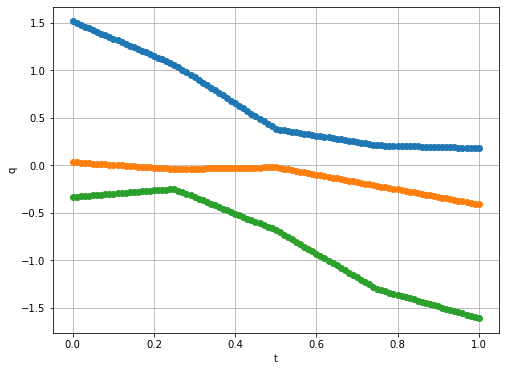

In [156]:
PublishPositionTrajectory(
        soln,
        diagram.CreateDefaultContext(),
        plant,
        diagram,
    )